In [1]:
import warnings
warnings.filterwarnings("ignore")

from tqdm import tqdm
import pandas as pd
import scanpy as sc
import anndata as ad
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
import matplotlib.patches as mpatches
import rapids_singlecell as rsc
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests
import matplotlib.colors as mcolors

sc.set_figure_params(frameon=False, dpi=80)

sc.settings.verbosity = 3               # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_version_and_date()

Running Scanpy 1.11.4, on 2026-08-27 09:20.


In [2]:
plot_folder = "/media/synology/Huijuan/Plots/IPF_subsets/IPF_paper/"
sc.settings.figdir = plot_folder
sc.set_figure_params(vector_friendly = True)

plt.rcParams["figure.figsize"] = (5, 5)
plt.rcParams.update({'font.size': 14})
plt.rcParams['pdf.fonttype'] = 42
sns.set_style("ticks")

## Define relative frequency function

In [3]:
def calc_relFreq(a, group_by="cell_type", xlabel="days", condition="batch"):
    freqs = a.obs.groupby(["batch", group_by]).size()
    samples = np.unique(a.obs["batch"])
    ind = a.obs[group_by].cat.categories

    relFreqs = [freqs[ident] / sum(freqs[ident]) for ident in samples]
    relFreqs = pd.DataFrame(relFreqs, columns=ind, index=samples).fillna(0)

    cell_types = {}
    combis = a.obs.groupby(["batch", xlabel]).groups.keys()

    for c in combis:
        cell_types[c[0]] = c[1]
    relFreqs[xlabel] = [cell_types[l] for l in relFreqs.index]

    if condition:
        combis = a.obs.groupby(["batch", condition]).groups.keys()
        for c in combis:
            cell_types[c[0]] = c[1]
        relFreqs[condition] = [cell_types[l] for l in relFreqs.index]

    return relFreqs

In [4]:
def plot_cluster_composition(
    relFreqs,
    xlabel="name",
    figsize=(6, 10),
    width=0.8,
    order=None,
    errbar=None,
    labelsize=15,
    ticksize=13,
    capsize=None,
    margins=(0.02, 0.04),
    cols=None,
    save=None,
):
    """
    Given a relative frequency table, plot the values as a stacked barplot.
    """

    patches = []

    fig, ax = plt.subplots()
    fig.set_size_inches(figsize)

    order = np.unique(relFreqs[xlabel]) if order is None else order
    ci = 95 if errbar else None

    ax.margins(margins[0], margins[1])

    cell_types = np.flip(
        [col for col in relFreqs.columns if col not in ["identifier", xlabel]]
    )

    bars = pd.DataFrame(index=order, data=np.zeros(len(order)))
    plot_data = pd.DataFrame(relFreqs[xlabel])

    for i, typ in enumerate(cell_types):
        sum_up = [
            relFreqs[typ].values[i] + bars.loc[g].values[0]
            for i, g in enumerate(relFreqs[xlabel])
        ]

        plot_data[typ] = sum_up

        bars.iloc[:, 0] = (
            bars.iloc[:, 0]
            + relFreqs[[typ, xlabel]]
            .groupby(xlabel)
            .mean()
            .loc[order, typ]
        )

    for i, typ in enumerate(reversed(cell_types)):
        sns.barplot(
            data=plot_data,
            x=xlabel,
            y=typ,
            order=order,
            ci=ci,
            errcolor="black",
            color=cols[i] if cols is not None else None,
            capsize=capsize,
            ax=ax,
        )

        patches.append(
            mpatches.Patch(
                color=cols[i] if cols is not None else None,
                label=typ,
            )
        )

    ax.set_xlabel(xlabel, size=labelsize)
    ax.set_ylabel("relative frequency", size=labelsize)
    ax.tick_params(labelsize=ticksize)
    ax.set_xticklabels(order, rotation="vertical")

    # Change bar widths
    for bar in ax.patches:
        centre = bar.get_x() + bar.get_width() / 2.0
        bar.set_x(centre - width / 2.0)
        bar.set_width(width)

    plt.legend(
        handles=patches,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        prop={"size": ticksize},
        frameon=False,
    )

    fig.subplots_adjust(right=0.85)

    if save:
        fig.savefig(
            save,
            bbox_inches="tight",
            pad_inches=0.3,
            dpi=300,
        )
        print(f"Saving Figure to {save}")

    plt.show()
    plt.close()

### Load object

In [5]:
object_folder  = "/media/HDD_1/sc_data_objects/FibFoci/" 
adata = sc.read(object_folder + "18082026_snRNA_IPF_annotation_final.h5ad")  
adata

AnnData object with n_obs × n_vars = 63072 × 31116
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'souporcell_assignment', 'souporcell_singlet_posterior', 'souporcell_doublet_posterior', 'souporcell_log_prob_singleton', 'souporcell_log_prob_doublet', 'souporcell_cluster0', 'souporcell_cluster1', 'souporcell_cluster2', 'ident', 'sum', 'detected', 'subsets_Ribo_sum', 'subsets_Ribo_detected', 'subsets_Ribo_percent', 'total', 'scDblFinder.cluster', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.difficulty', 'scDblFinder.cxds_score', 'scDblFinder.mostLikelyOrigin', 'scDblFinder.originAmbiguous', '_scvi_batch', '_scvi_labels', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'S.Score', 'G2M.Score', 'Phase', 'nCount_SCT', 'nFeature_SCT', 'souporcell_cluster3', 'sex', 'batch', 'Level_1', 'Level_2', 'Level_3', 'cell_type', 'severity', 'name', 'meta', 'ashcroft score', 'fibrosis extent', 'surface density'
    var: 'name', 'highly_variable', 

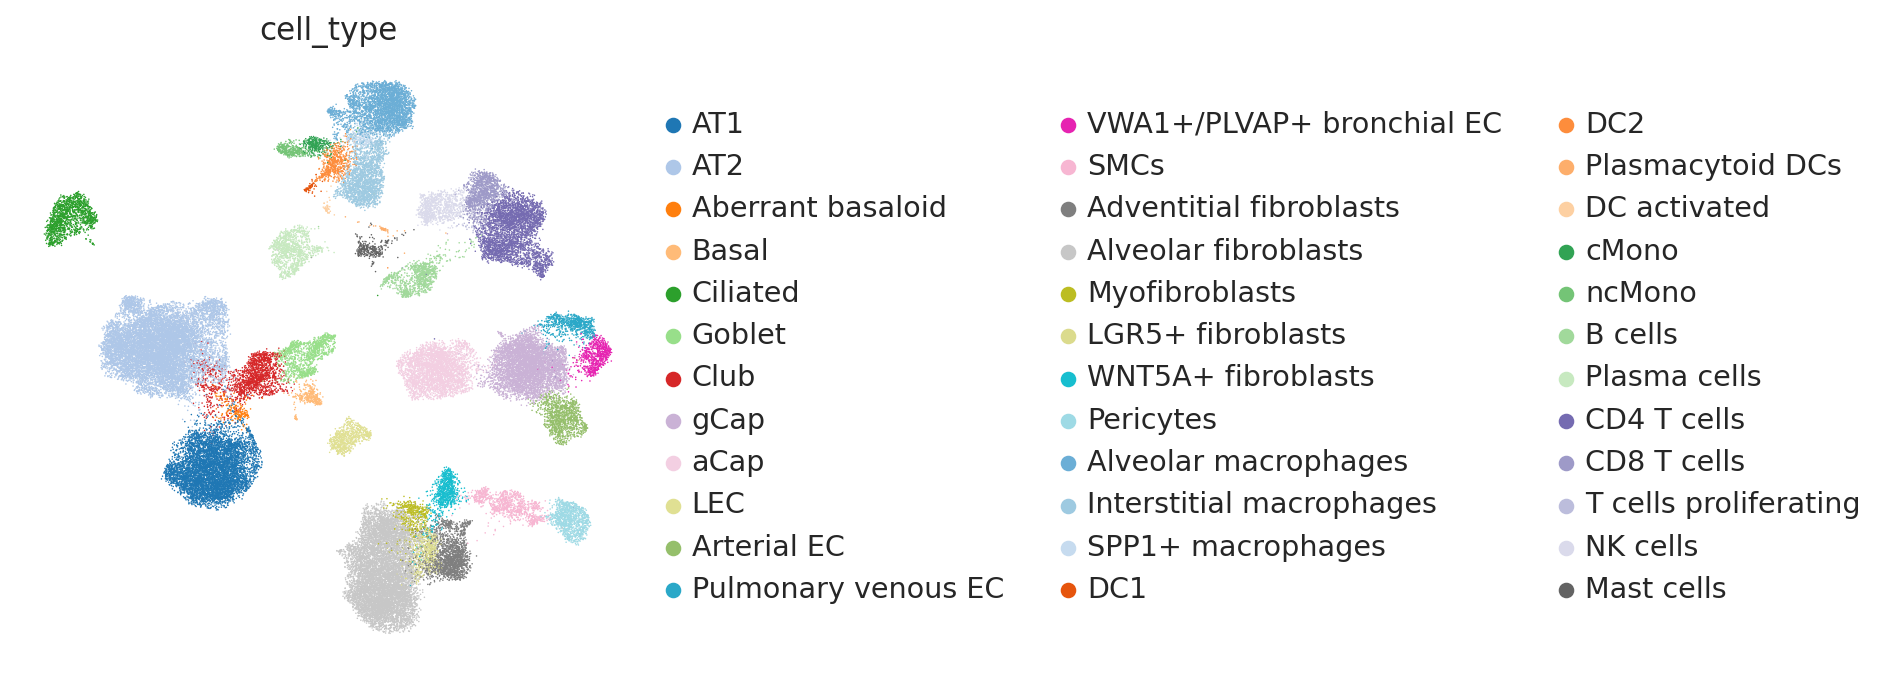

In [6]:
sc.pl.umap(adata, color = ["cell_type"], wspace = 0.2, frameon= False) #36

In [7]:
len(list(adata.obs.cell_type.unique()))

36

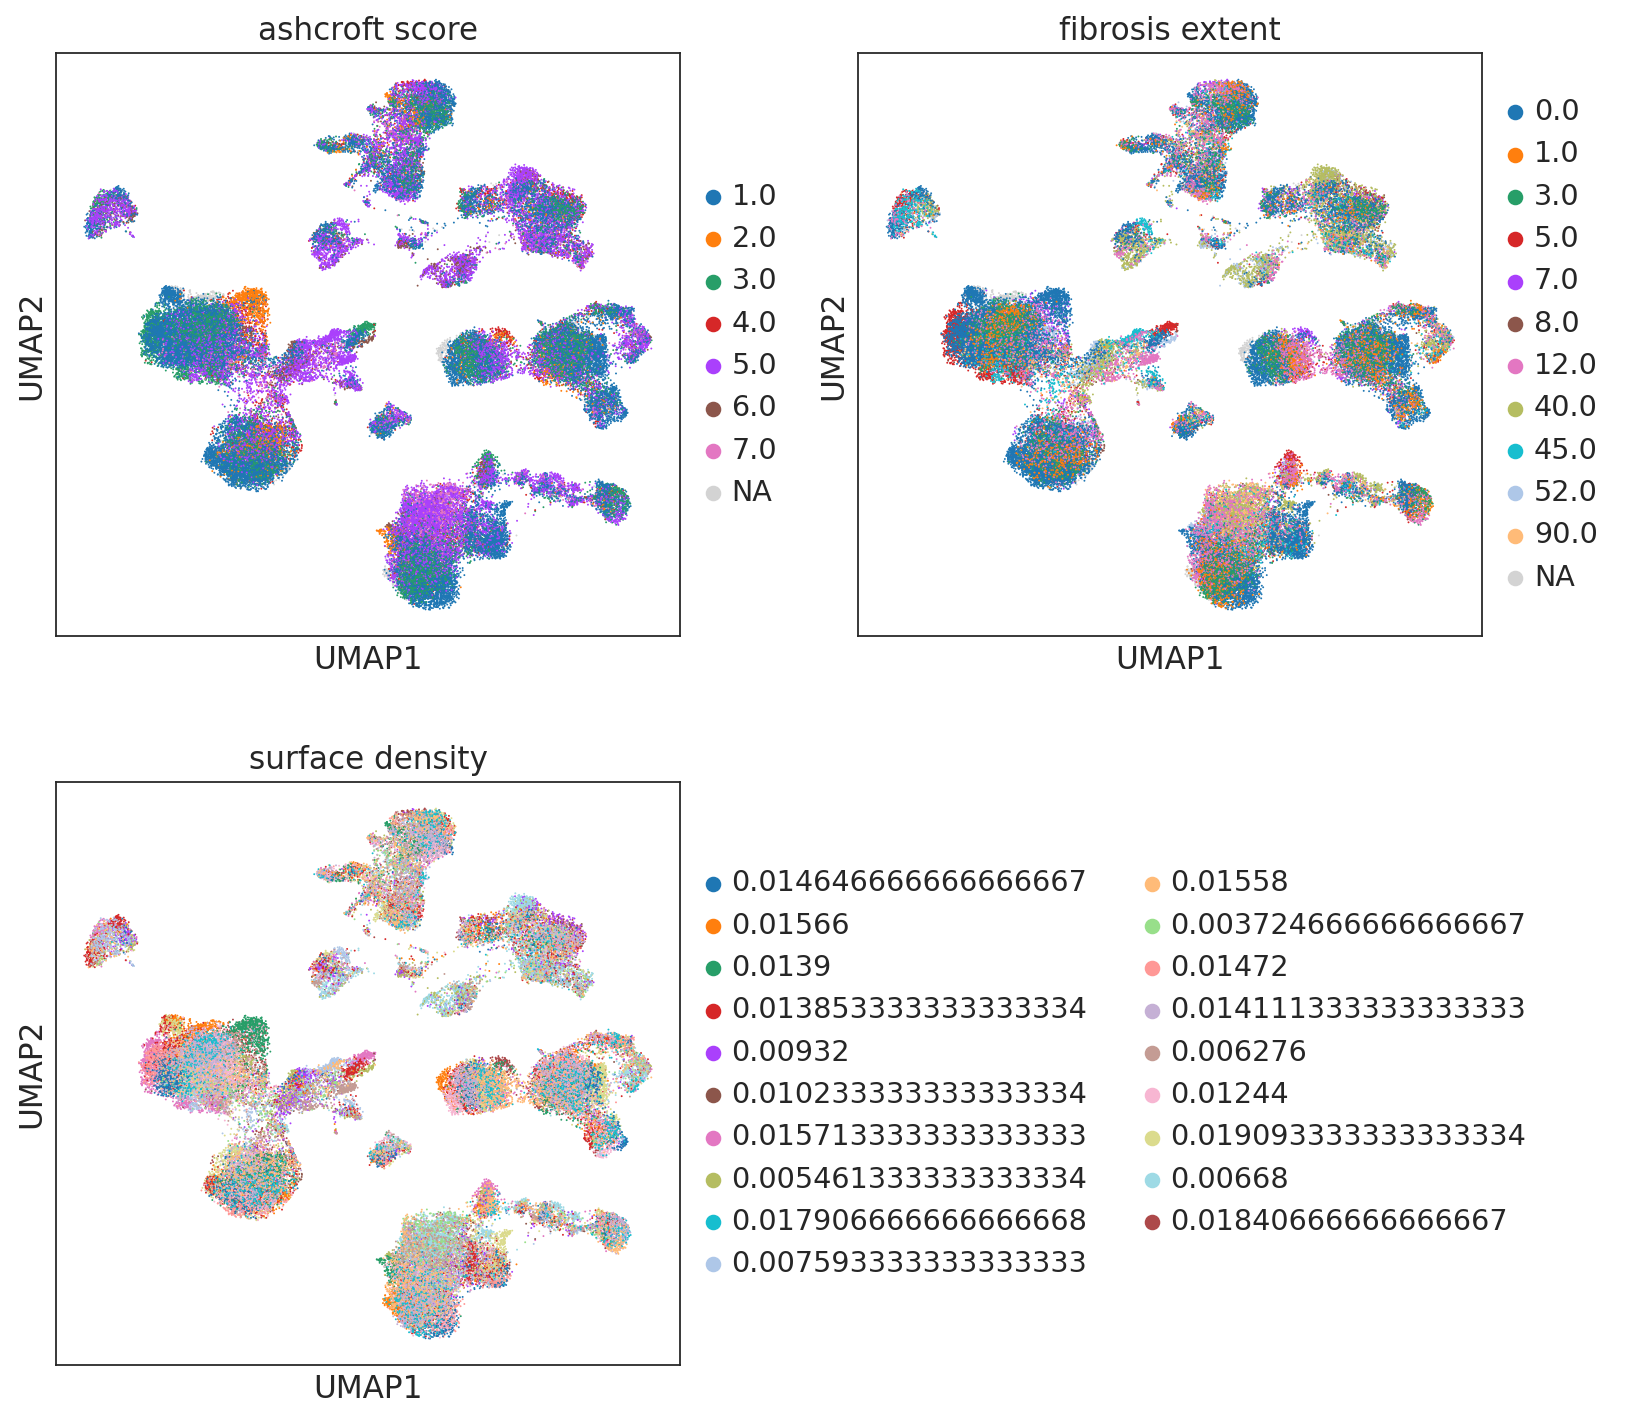

In [8]:
sc.pl.umap(adata, color = ["ashcroft score", "fibrosis extent", "surface density"], size = 3, ncols=2)

## Remove NA in ashcroft score and fibrosis extent

In [9]:
# Remove cells with NA in fibrosis extent
adata1 = adata[~adata.obs["ashcroft score"].isna()].copy()
adata1.shape

(60714, 31116)

In [10]:
adata1.obs["batch"] = adata1.obs["name"].copy()

xlabel = "name"
ct_label = "cell_type"
cols = adata1.uns[f"{ct_label}_colors"]
order = adata1.obs[xlabel].cat.categories.values
celltypes = adata1.obs[ct_label].cat.categories

# sample-level relative frequencies
relFreqs = calc_relFreq(adata1, group_by = ct_label , xlabel = xlabel, condition=None) 
relFreqs.head(10)

,AT1,AT2,Aberrant basaloid,Basal,Ciliated,Goblet,Club,gCap,aCap,LEC,...,cMono,ncMono,B cells,Plasma cells,CD4 T cells,CD8 T cells,T cells proliferating,NK cells,Mast cells,name
A101_IPFMild,0.092426,0.094761,0.005005,0.002336,0.012679,0.019686,0.007007,0.104771,0.146146,0.011011,...,0.008008,0.006006,0.003337,0.001668,0.028695,0.008008,0.000334,0.013680,0.001001,A101_IPFMild
A101_IPFSevere,0.007187,0.113963,0.046201,0.003080,0.005133,0.034908,0.026694,0.013347,0.002053,0.020534,...,0.003080,0.000000,0.012320,0.006160,0.067762,0.022587,0.001027,0.001027,0.004107,A101_IPFSevere
A124_Control,0.113682,0.248491,0.000000,0.000000,0.000000,0.000000,0.001509,0.120724,0.071932,0.011569,...,0.005030,0.006539,0.000503,0.001509,0.037223,0.003521,0.000000,0.011066,0.002012,A124_Control
A131_IPFMild,0.088889,0.206433,0.000585,0.000000,0.000000,0.000000,0.001754,0.148830,0.082749,0.004678,...,0.001170,0.013158,0.001170,0.004386,0.058187,0.003216,0.000877,0.015205,0.000292,A131_IPFMild
A131_IPFSevere,0.024490,0.107029,0.006349,0.008163,0.013152,0.097506,0.073923,0.007710,0.004989,0.010884,...,0.000907,0.000454,0.030385,0.028571,0.034467,0.010884,0.000000,0.002268,0.009977,A131_IPFSevere
A157_Control,0.111442,0.318065,0.000000,0.000000,0.000793,0.000000,0.017648,0.115606,0.044220,0.014277,...,0.003966,0.008923,0.000198,0.004164,0.013087,0.005156,0.000198,0.008328,0.001586,A157_Control
A159_Control,0.166712,0.228167,0.000000,0.000943,0.005795,0.001078,0.005256,0.086388,0.053504,0.011321,...,0.006469,0.004717,0.002695,0.008625,0.044474,0.011456,0.000135,0.015499,0.007817,A159_Control
A166_IPFMild,0.121065,0.151250,0.012658,0.000000,0.000649,0.000325,0.002921,0.095748,0.056800,0.009088,...,0.005193,0.007465,0.001623,0.017202,0.094450,0.027264,0.003570,0.036352,0.002921,A166_IPFMild
A166_IPFSevere,0.005385,0.047725,0.008728,0.003157,0.007799,0.001671,0.025441,0.004457,0.001114,0.012442,...,0.002228,0.000371,0.088208,0.059610,0.151161,0.090808,0.000743,0.007057,0.003343,A166_IPFSevere
A20_Control,0.133274,0.234562,0.000000,0.001333,0.008885,0.003998,0.012883,0.102177,0.066193,0.024878,...,0.004887,0.007108,0.007108,0.004887,0.026211,0.014216,0.000888,0.024434,0.003110,A20_Control


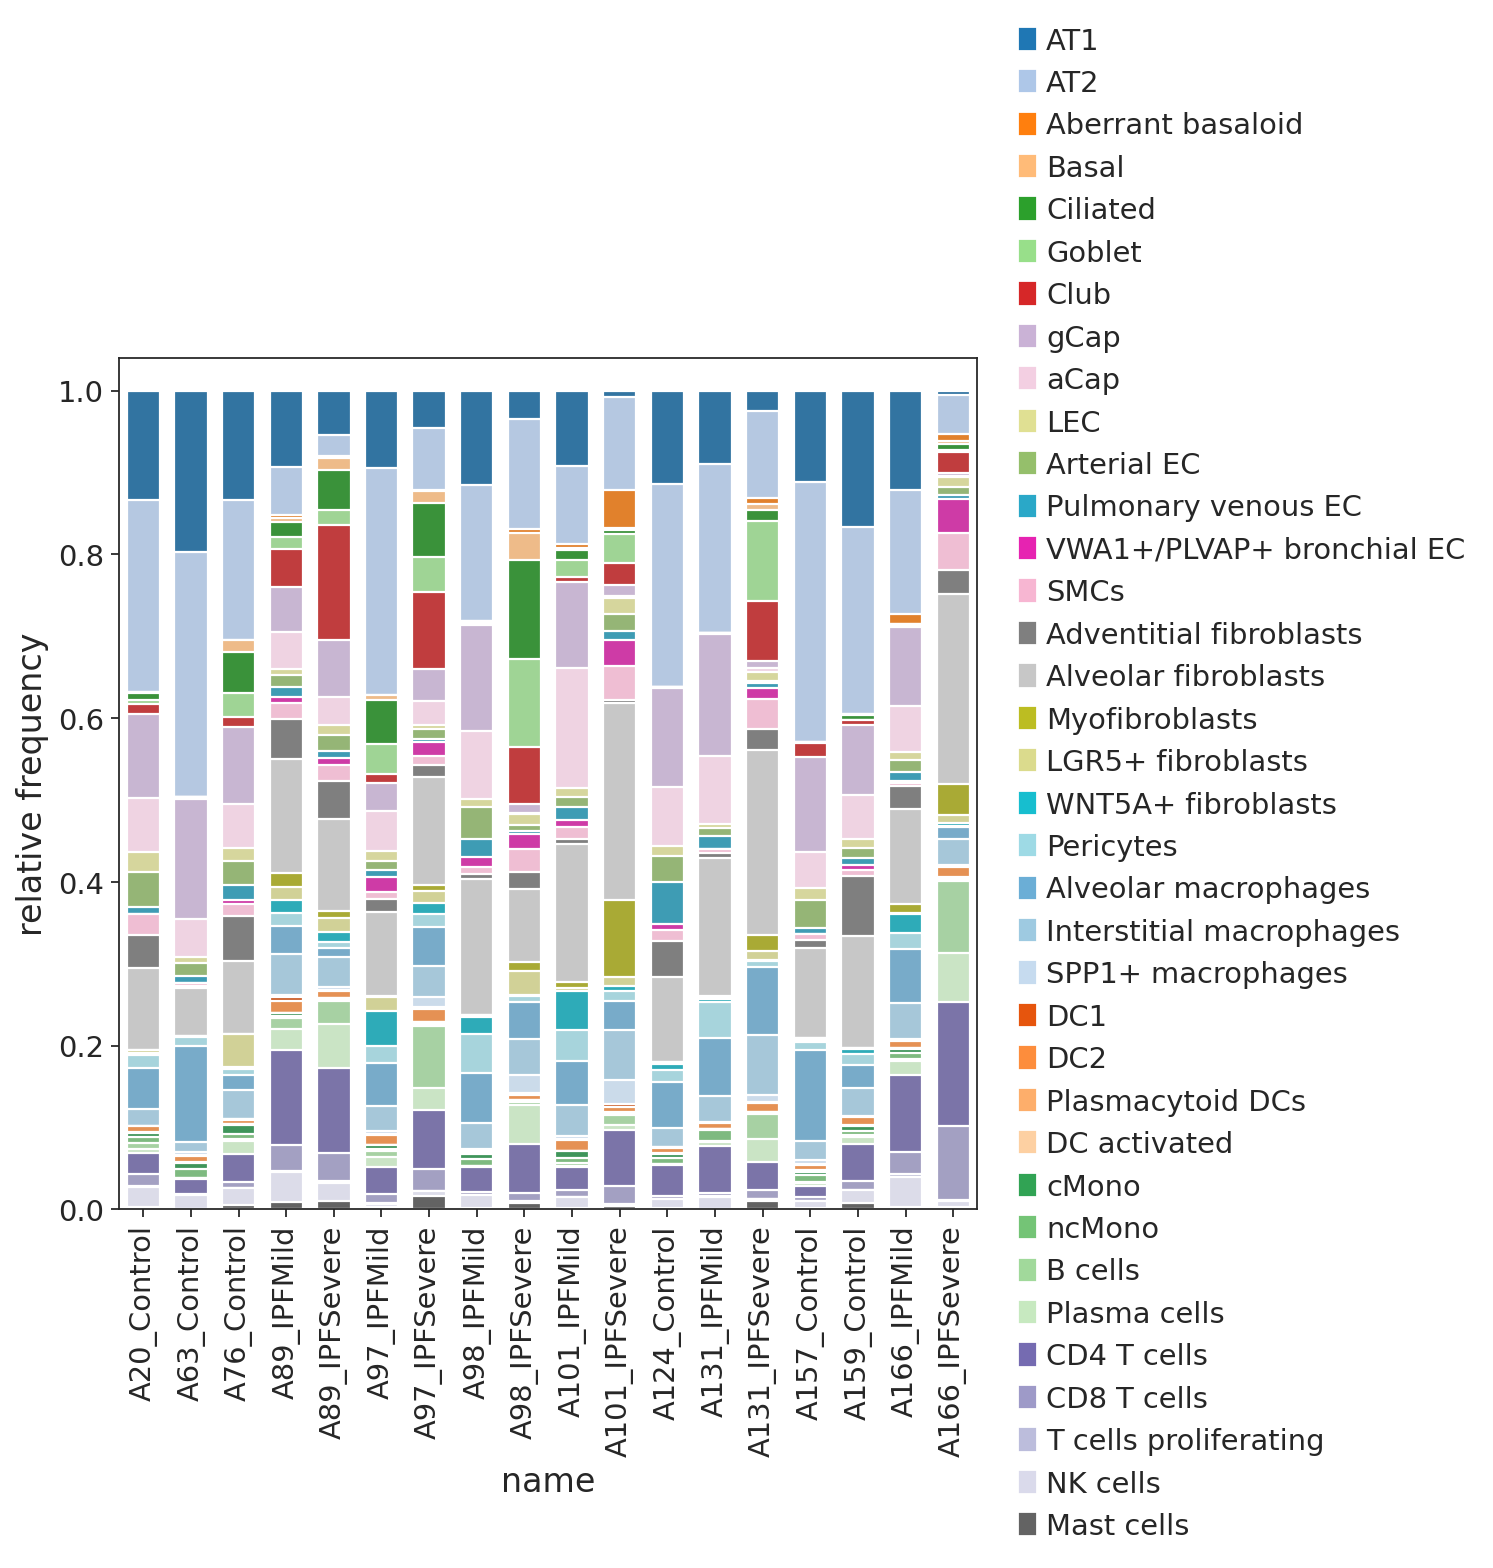

In [11]:
plot_cluster_composition(relFreqs, xlabel = xlabel, figsize = (8, 7), cols = cols, 
                               order=order, width = 0.7, margins = (0.02, 0.04), ) 
                               #save = plot_folder + "ReFreq_IPF_ashcroft_score.pdf") #margins = (0.02, 0.04), 

In [12]:
# Create core-level metadata
SCORE_COLS = ["ashcroft score", "fibrosis extent"]

meta_indexed = (
    adata.obs
    .groupby("name")[SCORE_COLS]
    .first()
    .apply(pd.to_numeric, errors="coerce")
)
print(meta_indexed.head(3))

             ashcroft score  fibrosis extent
name                                        
A20_Control             1.0              0.0
A55_Control             NaN              NaN
A63_Control             2.0              0.0


In [13]:
# Keep only genuine cell-type columns
ct_cols = [c for c in relFreqs.columns if c in list(celltypes)]
ct_cols

['AT1',
 'AT2',
 'Aberrant basaloid',
 'Basal',
 'Ciliated',
 'Goblet',
 'Club',
 'gCap',
 'aCap',
 'LEC',
 'Arterial EC',
 'Pulmonary venous EC',
 'VWA1+/PLVAP+ bronchial EC',
 'SMCs',
 'Adventitial fibroblasts',
 'Alveolar fibroblasts',
 'Myofibroblasts',
 'LGR5+ fibroblasts',
 'WNT5A+ fibroblasts',
 'Pericytes',
 'Alveolar macrophages',
 'Interstitial macrophages',
 'SPP1+ macrophages',
 'DC1',
 'DC2',
 'Plasmacytoid DCs',
 'DC activated',
 'cMono',
 'ncMono',
 'B cells',
 'Plasma cells',
 'CD4 T cells',
 'CD8 T cells',
 'T cells proliferating',
 'NK cells',
 'Mast cells']

In [14]:
scores_aligned = meta_indexed.reindex(relFreqs.index)   # (n_cores × n_scores)
 
shared_cores = scores_aligned.dropna(how="all").index
print(f"  Cores with ≥1 valid score : {len(shared_cores)}")
 
relFreqs_sub = relFreqs.loc[shared_cores, ct_cols]
scores_sub   = scores_aligned.loc[shared_cores]

  Cores with ≥1 valid score : 18


In [15]:
# Spearman rho + BH-FDR per (score, cell_type)
n_scores = len(SCORE_COLS)
n_cts    = len(ct_cols)
 
rho_mat  = np.zeros((n_scores, n_cts))
pval_mat = np.ones( (n_scores, n_cts))
 
for i, score_col in enumerate(SCORE_COLS):
    score_vals = scores_sub[score_col].values
    valid      = ~np.isnan(score_vals)
 
    raw_pvals = np.ones(n_cts)
    for j, ct in enumerate(ct_cols):
        x = relFreqs_sub[ct].values[valid]
        y = score_vals[valid]
        if x.std() == 0 or len(x) < 5:
            continue
        rho, p        = spearmanr(x, y)
        rho_mat[i, j] = rho
        raw_pvals[j]  = p
     #Benjamini-Hochberg correction controls false discoveries
    _, padj, _, _ = multipletests(raw_pvals, method="fdr_bh")
    pval_mat[i]   = padj
 
padj_mat = pval_mat
 
 
def sig_label(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return ""

In [16]:
# Rank columns by chosen score rho (descending: most positive → most negative)
RANK_BY_IDX = 1   # 0 = rank by ashcroft score, 1 = rank by fibrosis extent 
col_order    = np.argsort(rho_mat[RANK_BY_IDX])[::-1]
 
ct_ordered   = [ct_cols[i] for i in col_order]
rho_ordered  = rho_mat[:, col_order]
padj_ordered = padj_mat[:, col_order]
 
n_rows = n_scores
n_cols = n_cts

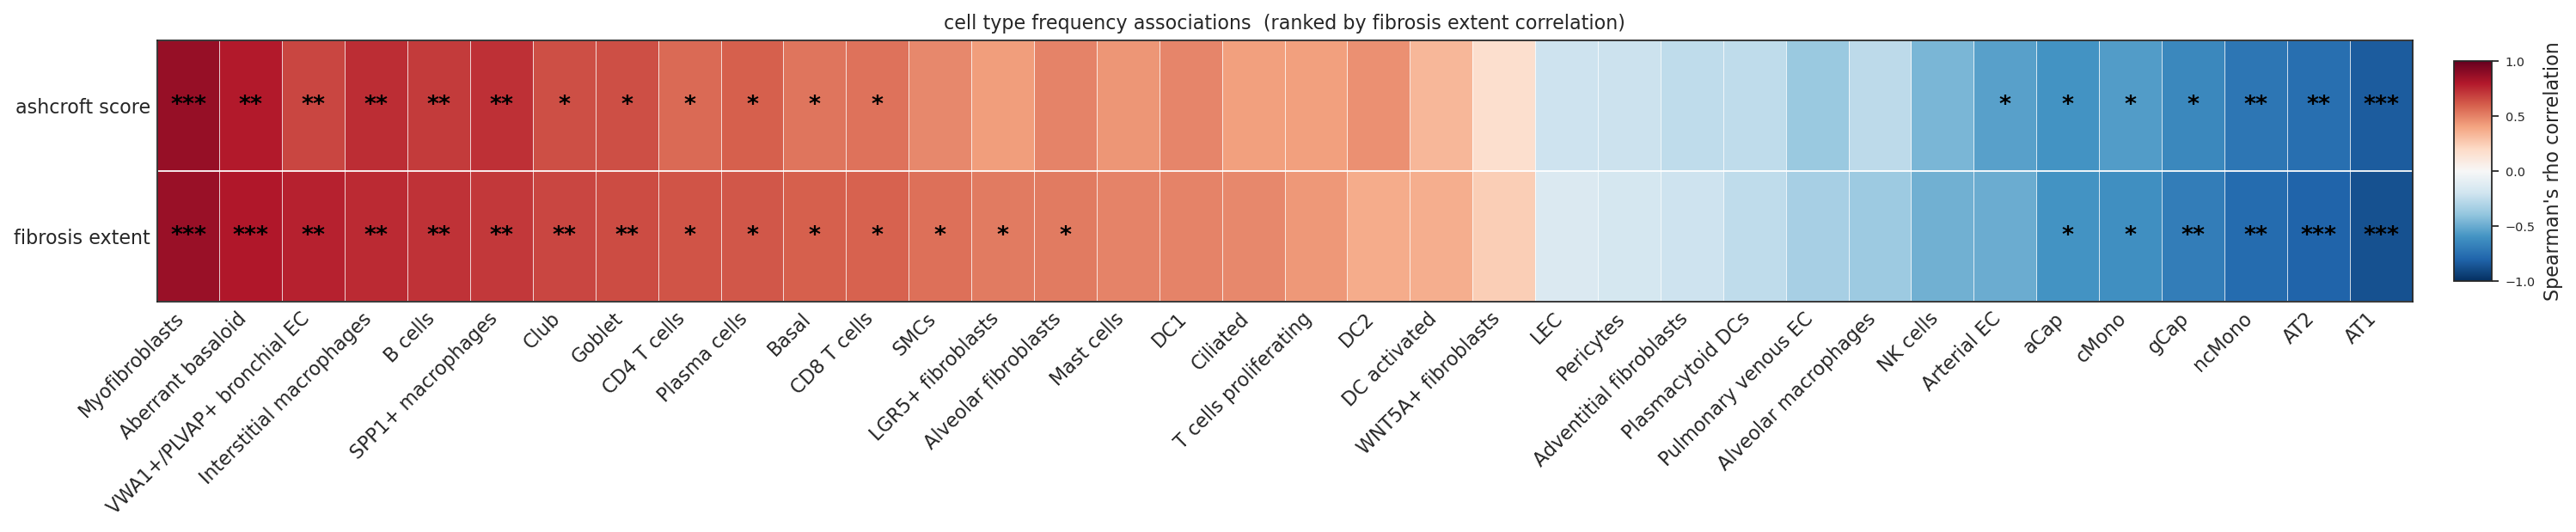

In [17]:
fig_w = max(20, n_cols * 0.36)
fig_h = 5.0
 
fig = plt.figure(figsize=(fig_w, fig_h))
 
left_margin  = 0.10   # space for y-axis labels
right_margin = 0.92   # right edge of heatmap / dendrogram
cbar_left    = 0.935
heat_bottom  = 0.22
heat_height  = 0.38
 
ax_heat = fig.add_axes([left_margin, heat_bottom, right_margin - left_margin, heat_height])
ax_cbar = fig.add_axes([cbar_left,   heat_bottom + 0.03, 0.014, heat_height - 0.06])

# ── 8. Title ──────────────────────────────────────────────────────────────────
rank_label = SCORE_COLS[RANK_BY_IDX]
ax_heat.set_title(
    f"cell type frequency associations  (ranked by {rank_label} correlation)",
    fontsize=10, pad=6
)

# ── 9. Heatmap ────────────────────────────────────────────────────────────────
cmap = plt.cm.RdBu_r
norm = mcolors.Normalize(-1, 1)
 
ax_heat.imshow(rho_ordered, aspect="auto", cmap=cmap, norm=norm,
               interpolation="nearest")
 
# Significance annotations
for i in range(n_rows):
    for j in range(n_cols):
        lbl = sig_label(padj_ordered[i, j])
        if lbl:
            ax_heat.text(j, i, lbl, ha="center", va="center",
                         fontsize=12, color="black", fontweight="bold")
 
# X-axis: angled labels (45°)
ax_heat.set_xticks(np.arange(n_cols))
ax_heat.set_xticklabels(ct_ordered, rotation=45, fontsize=10, ha="right")
 
# Y-axis: score names on the left
ax_heat.set_yticks(np.arange(n_rows))
ax_heat.set_yticklabels(SCORE_COLS, fontsize=10)
ax_heat.yaxis.set_tick_params(length=0)
ax_heat.xaxis.set_tick_params(length=0)
 
# Thin white grid between tiles
for x in np.arange(-0.5, n_cols, 1):
    ax_heat.axvline(x, color="white", lw=0.35)
for y in np.arange(-0.5, n_rows, 1):
    ax_heat.axhline(y, color="white", lw=0.8)
 
 
# ── 10. Colorbar ──────────────────────────────────────────────────────────────
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cb = plt.colorbar(sm, cax=ax_cbar)
cb.set_label("Spearman's rho correlation", fontsize=10, rotation=90, labelpad=4)
cb.set_ticks([-1.0, -0.5, 0.0, 0.5, 1.0])
cb.ax.tick_params(labelsize=6.5)

# ── 11. Save ──────────────────────────────────────────────────────────────────
#out_path = plot_folder + 'snRNA_correlation_heatmap.pdf'
#plt.savefig(out_path, bbox_inches="tight")
#print(f"Saved → {out_path}")